In [1]:
import os
import sys

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/openjdk-17.jdk/Contents/Home"

from pyspark.sql import SparkSession
from dotenv import load_dotenv

load_dotenv()
cassandra_user = os.getenv("CASSANDRA_USER", "cassandra")
cassandra_password = os.getenv("CASSANDRA_PASSWORD", "cassandra")

# Inicializar Spark
spark = SparkSession.builder \
    .appName("Bluesky_OLAP_Processor") \
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0") \
    .config("spark.cassandra.connection.host", "10.15.20.24") \
    .config("spark.cassandra.connection.port", "9041") \
    .config("spark.cassandra.auth.username", cassandra_user) \
    .config("spark.cassandra.auth.password", cassandra_password) \
    .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
#print(f"Spark Inicializado con Java: {os.environ['JAVA_HOME']}")
print(f"Versión de Spark: {spark.version}")

26/04/29 12:06:28 WARN Utils: Your hostname, MacBook-Air-de-Abraham.local resolves to a loopback address: 127.0.0.1; using 10.10.97.191 instead (on interface en0)
26/04/29 12:06:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/abrahammartinezceron/.ivy2/cache
The jars for the packages stored in: /Users/abrahammartinezceron/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-21838360-8877-4ad9-ba5c-c698fcbda575;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.0 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.0 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found com.datastax.oss#java-driver-core-shaded;4.13.0 in central
	found com.datastax.oss#native-protocol;1.5.0 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-j

:: loading settings :: url = jar:file:/Users/abrahammartinezceron/Documents/ProyectoFinalNoSQL/proyecto/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams;1.0.3 in central
	found com.github.stephenc.jcip#jcip-annotations;1.0-1 in central
	found com.github.spotbugs#spotbugs-annotations;3.1.12 in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found com.datastax.oss#java-driver-mapper-runtime;4.13.0 in central
	found com.datastax.oss#java-driver-query-builder;4.13.0 in central
	found org.apache.commons#commons-lang3;3.10 in central
	found com.thoughtworks.paranamer#paranamer;2.8 in central
	found org.scala-lang#scala-reflect;2.12.11 in central
:: resolution report :: resolve 211ms :: artifacts dl 26ms
	:: modules in use:
	com.datastax.oss#java-driver-core-shaded;4.13.0 from central in [default]
	com.datastax.oss#java-driver-mapper-runtime;4.13.0 from central in [default]
	com.dat

Versión de Spark: 3.5.1


In [2]:
df_raw = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="events", keyspace="jetstream_data") \
    .load()

print(f"Total de registros crudos en Cassandra: {df_raw.count()}")
df_raw.show(5, truncate=False)

Total de registros crudos en Cassandra: 391


+---------------------+----------------+--------------------------------+------+---------+--------------------------------------------------------------------------------------------------------------------------+-------------+
|collection           |time_us         |did                             |kind  |operation|record                                                                                                                    |rkey         |
+---------------------+----------------+--------------------------------+------+---------+--------------------------------------------------------------------------------------------------------------------------+-------------+
|app.bsky.graph.follow|1776096831568930|did:plc:62kuirr4abdcujvgkg5zcz6v|commit|delete   |null                                                                                                                      |3mjfb4dryct2x|
|app.bsky.graph.follow|1776096831559607|did:plc:xvqbjvr7mvy3auir5ojjaawy|commit|create  

In [3]:
import requests
from pyspark.sql.functions import col, get_json_object, to_timestamp, udf
from pyspark.sql.types import StringType

# --- 1. LIMPIEZA Y TRANSFORMACIÓN ---
df_clean = df_raw.withColumn("subject_did", get_json_object(col("record"), "$.subject")) \
                 .withColumn("timestamp", to_timestamp(col("time_us") / 1000000)) \
                 .select("collection", "timestamp", "operation", "did", "subject_did")

# --- 2. ENRIQUECIMIENTO (Resolución de DIDs) ---
# Un pequeño caché para no pedir el mismo usuario a la API dos veces
did_cache = {}

def resolve_did(did):
    if not did: return None
    if did in did_cache: return did_cache[did]
    
    try:
        url = f"https://public.api.bsky.app/xrpc/com.atproto.identity.resolveIdentity?did={did}"
        response = requests.get(url, timeout=2)
        if response.status_code == 200:
            handle = response.json().get("handle")
            did_cache[did] = handle
            return handle
    except:
        pass # Si la API falla, ignoramos
    
    return did # Si no encuentra el handle, devolvemos el DID original para no perder datos

# Convertir la función de Python a una función que Spark entienda (UDF)
resolve_udf = udf(resolve_did, StringType())

# Aplicar la función a las columnas de actor y sujeto
print("Transformando y enriqueciendo datos (resolviendo DIDs)...")
df_enriched = df_clean.withColumn("actor_handle", resolve_udf(col("did"))) \
                      .withColumn("subject_handle", resolve_udf(col("subject_did")))

# Seleccionamos las columnas finales y las mostramos
df_final = df_enriched.select("timestamp", "collection", "operation", "actor_handle", "subject_handle")

df_final.show(10, truncate=False)

Transformando y enriqueciendo datos (resolviendo DIDs)...


+--------------------------+---------------------+---------+--------------------------------+--------------------------------+
|timestamp                 |collection           |operation|actor_handle                    |subject_handle                  |
+--------------------------+---------------------+---------+--------------------------------+--------------------------------+
|2026-04-13 10:13:51.56893 |app.bsky.graph.follow|delete   |did:plc:62kuirr4abdcujvgkg5zcz6v|NULL                            |
|2026-04-13 10:13:51.559607|app.bsky.graph.follow|create   |did:plc:xvqbjvr7mvy3auir5ojjaawy|did:plc:y5l4fp5ciyxya5i624ej5tjd|
|2026-04-13 10:13:51.514988|app.bsky.graph.follow|create   |did:plc:w2pyjru2yjf4mudhnfbpo74c|did:plc:tf55xtvv553u6zqsd6gziy5l|
|2026-04-13 10:13:51.416299|app.bsky.graph.follow|delete   |did:plc:d2pi6trtljikqvoifxuytkar|NULL                            |
|2026-04-13 10:13:51.415426|app.bsky.graph.follow|delete   |did:plc:hmhdvkw7i5iddgpjebk5co5n|NULL              

In [4]:
from pyspark.sql.functions import col, window, desc, count, when, row_number
from pyspark.sql.window import Window

print("--- INICIANDO ANÁLISIS DE RESULTADOS ---")

# Filtrar nulos para los análisis que requieren un receptor (subject)
df_valid_subjects = df_final.filter(col("subject_handle").isNotNull())

# ---------------------------------------------------------
# CONSULTA 1: Tendencia de Actividad (Time-Series Aggregation)
# Muestra el volumen de eventos (Follows vs Blocks) por ventanas de 1 minuto.
# Útil para detectar picos de actividad o anomalías en el stream.
# ---------------------------------------------------------
print("\n1. Tendencia de Actividad por Minuto:")
df_trend = df_final.groupBy(
    window(col("timestamp"), "1 minute"), 
    col("collection")
).count().orderBy(col("window.start").desc())

df_trend.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 2: Identificación de "Spammers" o Cuentas Altamente Activas
# Agregación masiva para encontrar quiénes están dando más follows o blocks.
# (Centralidad de Grado de Salida / Out-Degree en grafos)
# ---------------------------------------------------------
print("\n2. Usuarios Más Activos (Out-Degree):")
df_active_actors = df_final.groupBy("actor_handle") \
                           .count() \
                           .orderBy(desc("count"))

df_active_actors.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 3: Top Influencers y Cuentas Polémicas
# ¿Quiénes están recibiendo más interacciones? 
# (Centralidad de Grado de Entrada / In-Degree)
# ---------------------------------------------------------
print("\n3. Usuarios Más Receptores (In-Degree):")
df_top_targets = df_valid_subjects.groupBy("subject_handle", "collection") \
                                  .count() \
                                  .orderBy(desc("count"))

df_top_targets.show(5, truncate=False)

# ---------------------------------------------------------
# CONSULTA 4: Proporción de Sentimiento de la Red (Follows vs Blocks)
# Uso de agregación condicional para evaluar el "humor" del stream capturado.
# ---------------------------------------------------------
print("\n4. Proporción General de Interacciones:")
df_ratio = df_final.groupBy().agg(
    count(when(col("collection") == "app.bsky.graph.follow", True)).alias("Total_Follows"),
    count(when(col("collection") == "app.bsky.graph.block", True)).alias("Total_Blocks"),
    count("*").alias("Total_Eventos")
)

df_ratio.show(truncate=False)

# ---------------------------------------------------------
# CONSULTA 5: Líderes por Categoría (Window Functions)
# Consulta compleja que particiona los datos por tipo de evento y obtiene 
# el "Top 3" de usuarios más impactados en cada categoría (Follow y Block).
# ---------------------------------------------------------
print("\n5. Top 3 Usuarios Receptores Particionado por Colección (Window Function):")
windowSpec = Window.partitionBy("collection").orderBy(desc("count"))

df_ranked_targets = df_valid_subjects.groupBy("collection", "subject_handle").count() \
                                     .withColumn("rank", row_number().over(windowSpec))

df_top_3_per_category = df_ranked_targets.filter(col("rank") <= 3).orderBy("collection", "rank")

df_top_3_per_category.show(truncate=False)

--- INICIANDO ANÁLISIS DE RESULTADOS ---

1. Tendencia de Actividad por Minuto:


+------------------------------------------+---------------------+-----+
|window                                    |collection           |count|
+------------------------------------------+---------------------+-----+
|{2026-04-13 10:13:00, 2026-04-13 10:14:00}|app.bsky.graph.block |26   |
|{2026-04-13 10:13:00, 2026-04-13 10:14:00}|app.bsky.graph.follow|194  |
|{2026-04-06 17:26:00, 2026-04-06 17:27:00}|app.bsky.graph.block |16   |
|{2026-04-06 17:26:00, 2026-04-06 17:27:00}|app.bsky.graph.follow|155  |
+------------------------------------------+---------------------+-----+


2. Usuarios Más Activos (Out-Degree):


+--------------------------------+-----+
|actor_handle                    |count|
+--------------------------------+-----+
|did:plc:o6jpzsl5657twes4i4zhjafk|13   |
|did:plc:23iyixtz6a7hy44vf2h4kc4y|11   |
|did:plc:kebnleonupsok5x66g3fmz7a|9    |
|did:plc:yodwhbp6dtkyjhzbubfw5xw3|9    |
|did:plc:fwyhucenvxe4mci6t5ta4vs7|7    |
+--------------------------------+-----+
only showing top 5 rows


3. Usuarios Más Receptores (In-Degree):


+--------------------------------+---------------------+-----+
|subject_handle                  |collection           |count|
+--------------------------------+---------------------+-----+
|did:plc:z72i7hdynmk6r22z27h6tvur|app.bsky.graph.follow|3    |
|did:plc:rl35cn7a4yiildmlcj6l5idw|app.bsky.graph.follow|1    |
|did:plc:447baz4chyvqlfcvy4c33tl5|app.bsky.graph.follow|1    |
|did:plc:4ne6thek5veewv7gvjpnntsm|app.bsky.graph.follow|1    |
|did:plc:hfon4nvbjzvyqmp6u6fv2vvv|app.bsky.graph.follow|1    |
+--------------------------------+---------------------+-----+
only showing top 5 rows


4. Proporción General de Interacciones:


+-------------+------------+-------------+
|Total_Follows|Total_Blocks|Total_Eventos|
+-------------+------------+-------------+
|349          |42          |391          |
+-------------+------------+-------------+


5. Top 3 Usuarios Receptores Particionado por Colección (Window Function):


+---------------------+--------------------------------+-----+----+
|collection           |subject_handle                  |count|rank|
+---------------------+--------------------------------+-----+----+
|app.bsky.graph.block |did:plc:gn4q4qzc2tiabrp5bxzmyaqc|1    |1   |
|app.bsky.graph.block |did:plc:nkso3khus3yph4fudks47xod|1    |2   |
|app.bsky.graph.block |did:plc:abrrcul6zhs6hivcgo3p3gsm|1    |3   |
|app.bsky.graph.follow|did:plc:z72i7hdynmk6r22z27h6tvur|3    |1   |
|app.bsky.graph.follow|did:plc:zxzhnmk6xump5qs5uols74db|1    |2   |
|app.bsky.graph.follow|did:plc:oxhwp5ir2rse5ia7y72z4dqu|1    |3   |
+---------------------+--------------------------------+-----+----+



--- GENERANDO VISUALIZACIONES ANALÍTICAS ---
1. Graficando Proporción de Interacciones...


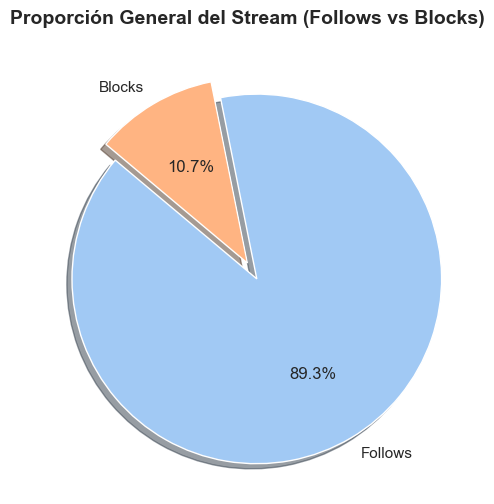

2. Graficando Tendencia de Actividad...


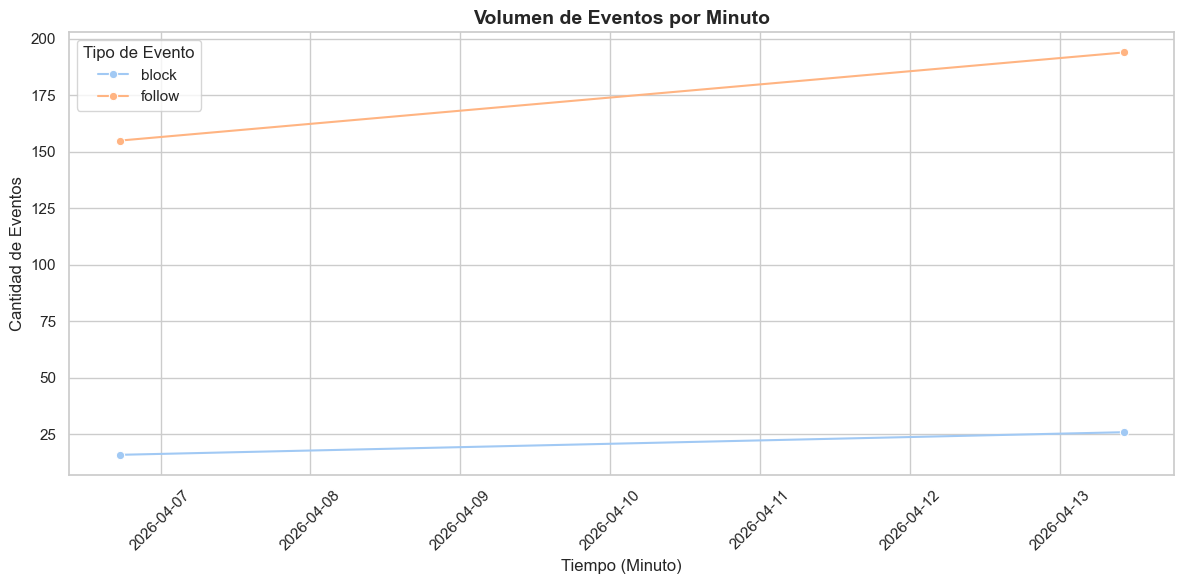

3. Graficando Top Usuarios Activos...


/var/folders/8r/lpfr7zcx7g5fd8bxyg6xysyw0000gn/T/ipykernel_30922/4094896077.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_active, x='count', y='actor_handle', palette='viridis')


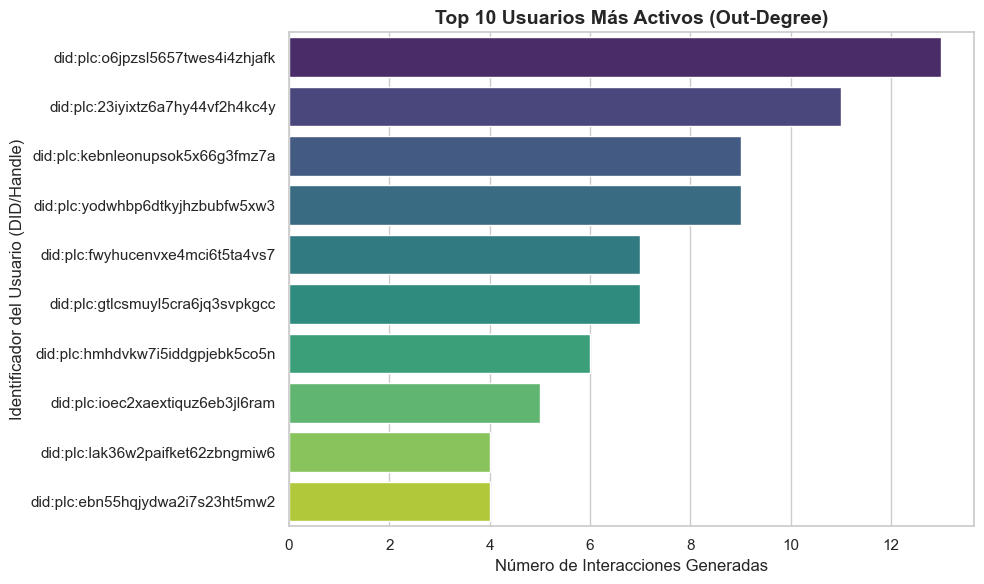

¡Gráficas generadas y guardadas como imágenes PNG en tu directorio!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

print("--- GENERANDO VISUALIZACIONES ANALÍTICAS ---")

# ==========================================
# Gráfica 1: Proporción de Interacciones (Pie Chart)
# Representa la "Consulta 4"
# ==========================================
print("1. Graficando Proporción de Interacciones...")
pd_ratio = df_ratio.toPandas()

labels = ['Follows', 'Blocks']
sizes = [pd_ratio['Total_Follows'][0], pd_ratio['Total_Blocks'][0]]
colors = sns.color_palette('pastel')[0:2]
explode = (0.1, 0) 

plt.figure()
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Proporción General del Stream (Follows vs Blocks)', fontsize=14, fontweight='bold')
plt.savefig('grafica_proporcion.png', bbox_inches='tight') # Guardar para el README
plt.show()

# ==========================================
# Gráfica 2: Tendencia de Actividad en el Tiempo (Line Plot)
# Representa la "Consulta 1"
# ==========================================
print("2. Graficando Tendencia de Actividad...")
pd_trend = df_trend.toPandas()

# Limpiar los datos para graficar: Extraer el inicio de la ventana y renombrar colecciones
pd_trend['timestamp'] = pd_trend['window'].apply(lambda x: x['start'])
pd_trend['collection'] = pd_trend['collection'].str.replace('app.bsky.graph.', '')

plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_trend, x='timestamp', y='count', hue='collection', marker='o')
plt.title('Volumen de Eventos por Minuto', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Minuto)', fontsize=12)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Tipo de Evento')
plt.tight_layout()
plt.savefig('grafica_tendencia.png') # Guardar para el README
plt.show()

# ==========================================
# Gráfica 3: Usuarios Más Activos (Bar Chart Horizontal)
# Representa la "Consulta 2"
# ==========================================
print("3. Graficando Top Usuarios Activos...")
pd_active = df_active_actors.limit(10).toPandas()

plt.figure()
sns.barplot(data=pd_active, x='count', y='actor_handle', palette='viridis')
plt.title('Top 10 Usuarios Más Activos (Out-Degree)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Interacciones Generadas', fontsize=12)
plt.ylabel('Identificador del Usuario (DID/Handle)', fontsize=12)
plt.tight_layout()
plt.savefig('grafica_activos.png') # Guardar para el README
plt.show()

print("¡Gráficas generadas y guardadas como imágenes PNG en tu directorio!")